# 📥 Step 1: Data Loading

Load Sentinel-2 satellite bands and explore the data structure.

## What This Notebook Does:
- ✅ Install required libraries
- ✅ Load multi-spectral bands (B02, B03, B04, B08)
- ✅ Check data dimensions and quality
- ✅ Visualize raw spectral bands
- ✅ Save loaded data for next steps

---

**Next:** [02_preprocessing.ipynb](02_preprocessing.ipynb) - Calculate NDVI and classify pixels

## Setup: Import Libraries

In [1]:
# Install required packages (uncomment if needed)
# !pip install numpy pandas matplotlib rasterio scikit-learn tensorflow jupyter

import numpy as np
import matplotlib.pyplot as plt
import rasterio
import pickle
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Rasterio version: {rasterio.__version__}")

✅ Libraries imported successfully!
NumPy version: 2.3.5
Rasterio version: 1.5.0


## Load Sentinel-2 Bands

**Sentinel-2 Bands:**
- **B02**: Blue (490 nm) - 10m resolution
- **B03**: Green (560 nm) - 10m resolution
- **B04**: Red (665 nm) - 10m resolution
- **B08**: Near-Infrared / NIR (842 nm) - 10m resolution

In [2]:
# Load Sentinel-2 bands from TIFF files
print("📂 Loading satellite bands...")

B02 = rasterio.open("coastalImage/B02.tiff").read(1).astype(float)  # Blue
B03 = rasterio.open("coastalImage/B03.tiff").read(1).astype(float)  # Green
B04 = rasterio.open("coastalImage/B04.tiff").read(1).astype(float)  # Red
B08 = rasterio.open("coastalImage/B08.tiff").read(1).astype(float)  # NIR

print(f"✅ Bands loaded successfully!")
print(f"\nImage dimensions: {B02.shape}")
print(f"Total pixels: {B02.size:,}")
print(f"\nBand statistics:")
print(f"  B02 (Blue)  - Min: {B02.min():.4f}, Max: {B02.max():.4f}, Mean: {B02.mean():.4f}")
print(f"  B03 (Green) - Min: {B03.min():.4f}, Max: {B03.max():.4f}, Mean: {B03.mean():.4f}")
print(f"  B04 (Red)   - Min: {B04.min():.4f}, Max: {B04.max():.4f}, Mean: {B04.mean():.4f}")
print(f"  B08 (NIR)   - Min: {B08.min():.4f}, Max: {B08.max():.4f}, Mean: {B08.mean():.4f}")

📂 Loading satellite bands...
✅ Bands loaded successfully!

Image dimensions: (424, 480)
Total pixels: 203,520

Band statistics:
  B02 (Blue)  - Min: 0.0047, Max: 0.5747, Mean: 0.0422
  B03 (Green) - Min: 0.0073, Max: 0.6626, Mean: 0.0452
  B04 (Red)   - Min: 0.0016, Max: 0.6380, Mean: 0.0269
  B08 (NIR)   - Min: 0.0000, Max: 0.6969, Mean: 0.0847


## Visualize Spectral Bands

B02 - Blue Band (490 nm): actual range [0.0221, 0.1055]
B03 - Green Band (560 nm): actual range [0.0146, 0.1280]
B04 - Red Band (665 nm): actual range [0.0038, 0.1322]
B08 - NIR Band (842 nm): actual range [0.0003, 0.4981]


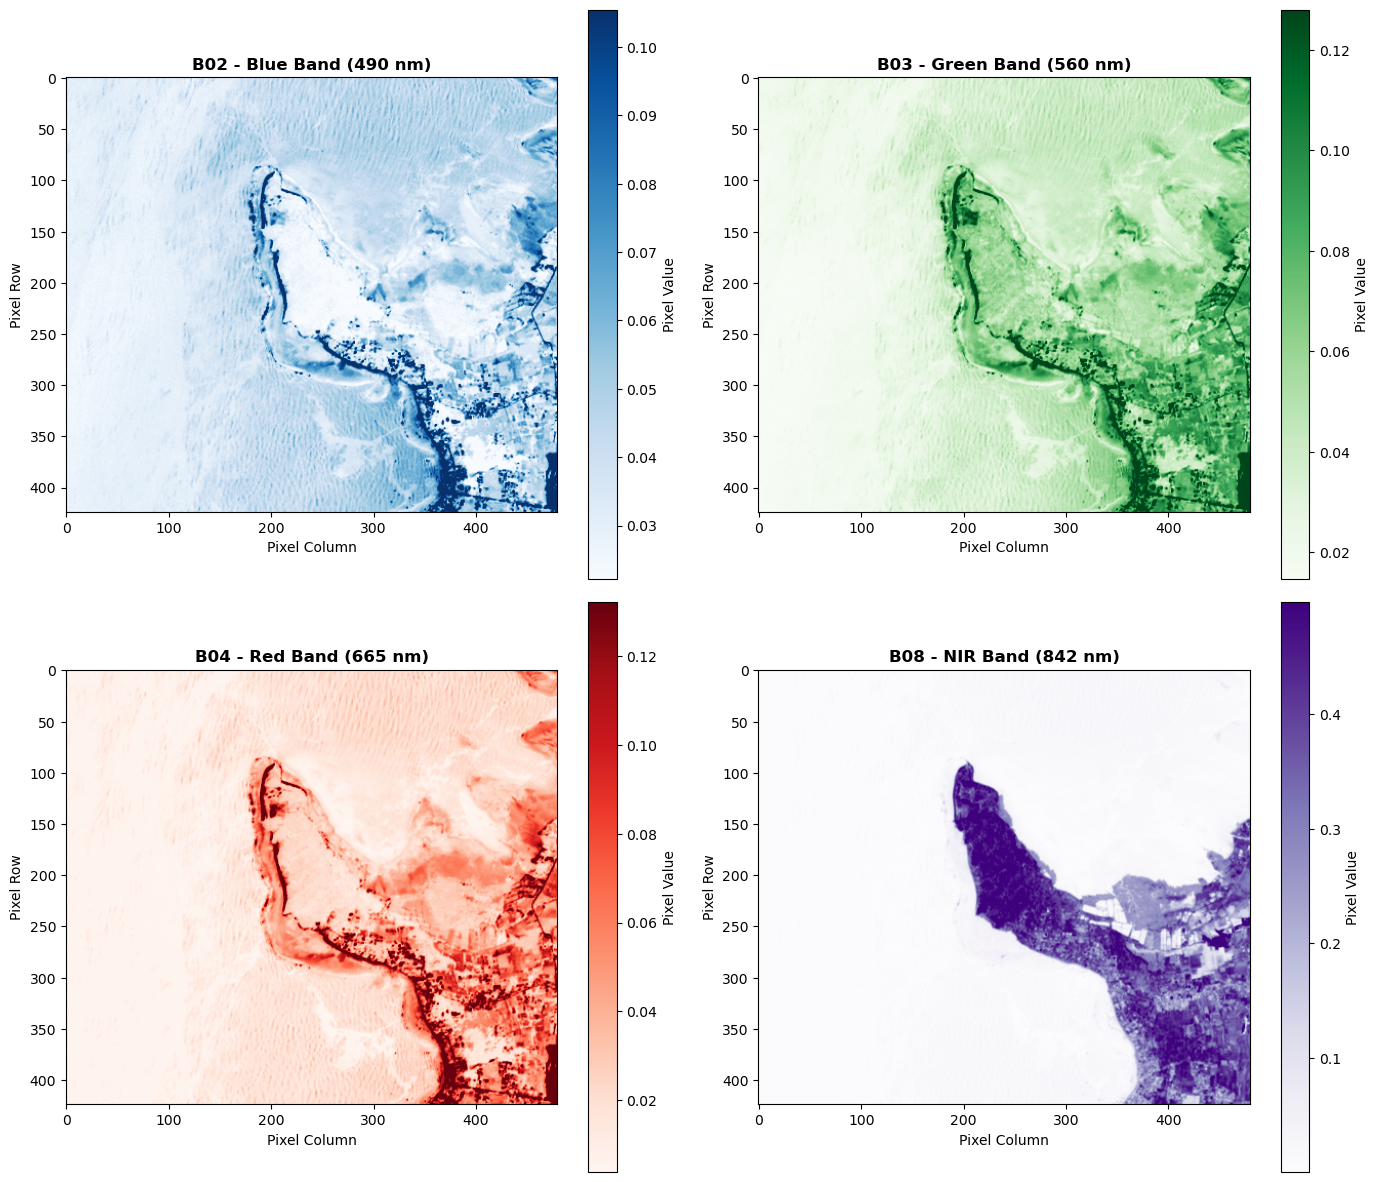

💾 Visualization saved to 'outputs/01_spectral_bands.png'


In [3]:
# Visualize all four bands
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

bands = [B02, B03, B04, B08]
titles = ['B02 - Blue Band (490 nm)', 'B03 - Green Band (560 nm)', 
          'B04 - Red Band (665 nm)', 'B08 - NIR Band (842 nm)']
cmaps = ['Blues', 'Greens', 'Reds', 'Purples']

for idx, (band, title, cmap) in enumerate(zip(bands, titles, cmaps)):
    ax = axes[idx // 2, idx % 2]
    
    # Filter out nodata values (-9999) AND NaN
    band_clean = band[(band > -9999) & (~np.isnan(band))]
    
    # Calculate percentile stretch on actual data range
    vmin = np.percentile(band_clean, 2)
    vmax = np.percentile(band_clean, 98)
    
    print(f"{title}: actual range [{vmin:.4f}, {vmax:.4f}]")
    
    im = ax.imshow(band, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Pixel Column')
    ax.set_ylabel('Pixel Row')
    cbar = plt.colorbar(im, ax=ax, label='Pixel Value')

plt.tight_layout()
plt.savefig('outputs/01_spectral_bands.png', dpi=300, bbox_inches='tight')
plt.show()

print("💾 Visualization saved to 'outputs/01_spectral_bands.png'")

## Save Loaded Bands

Save the loaded bands as a pickle file for use in the next notebook.

In [4]:
# Save bands to pickle file for next notebook
import os
os.makedirs('outputs', exist_ok=True)

bands_data = {
    'B02': B02,
    'B03': B03,
    'B04': B04,
    'B08': B08,
    'shape': B02.shape
}

with open('outputs/loaded_bands.pkl', 'wb') as f:
    pickle.dump(bands_data, f)

print("✅ Bands saved to 'outputs/loaded_bands.pkl'")
print("\n" + "="*60)
print("✅ DATA LOADING COMPLETE!")
print("="*60)
print("\n📌 Next Step: Open 02_preprocessing.ipynb to calculate NDVI")

✅ Bands saved to 'outputs/loaded_bands.pkl'

✅ DATA LOADING COMPLETE!

📌 Next Step: Open 02_preprocessing.ipynb to calculate NDVI
